<a href="https://colab.research.google.com/github/vighnesh-18/DiabetesPrediction/blob/main/DiabetesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.shape

(768, 9)

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


**NO MISSING VALUES**

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Data Imputations of 0's need to be fixed

Target column (0/1) : **Binary Classification**

As target data is avialable it is **Supervised ML Algo**

Records : 768

Corelation Coefficient

If range is nearer to -1 or +1 then that specific feature may be omitted

In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


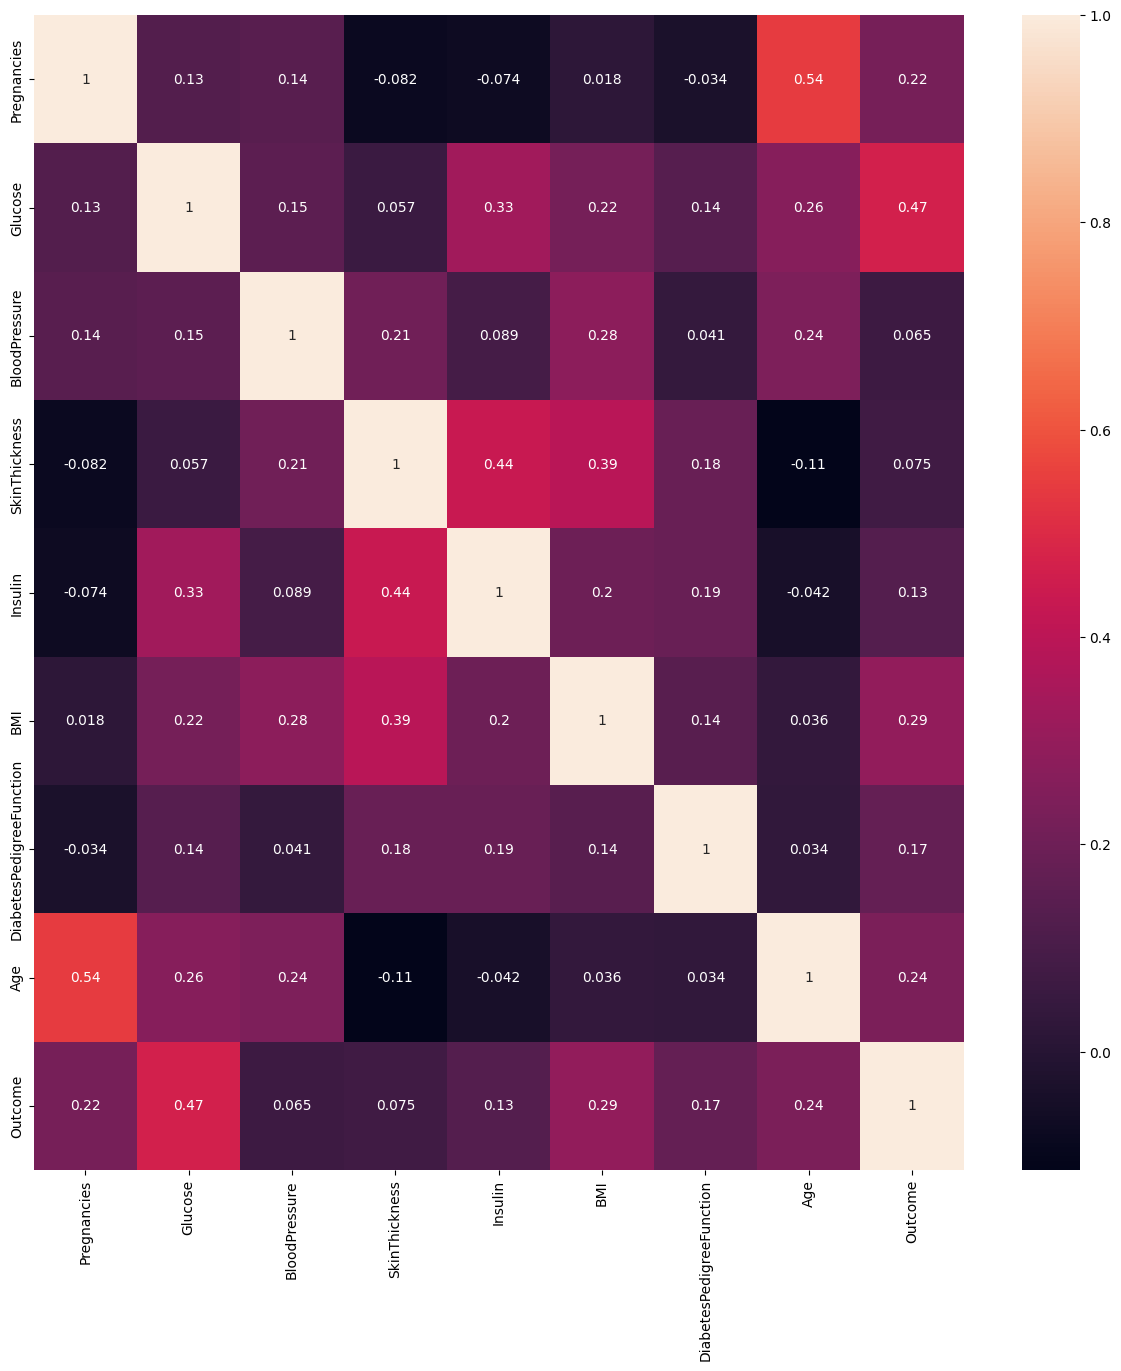

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True)
plt.savefig('corr-cf.jpg')
plt.show()

From heat map we can conclude that no feature has more corr cf, so all are equally important

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Imputation

Need to remove all wrong 0's

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Left Skewed Distribution: so use median to replace all 0's

<ipython-input-15-5183c8f00260>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Pregnancies)


<Axes: xlabel='Pregnancies', ylabel='Density'>

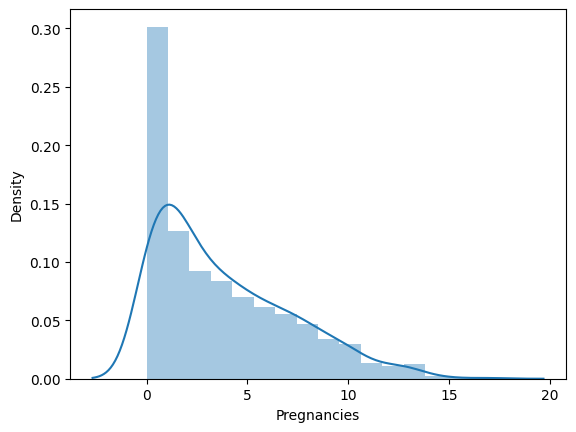

In [ ]:
sns.distplot(df.Pregnancies)

Use mean as it is normal distribution

<ipython-input-16-bb4494b983d6>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Glucose)


<Axes: xlabel='Glucose', ylabel='Density'>

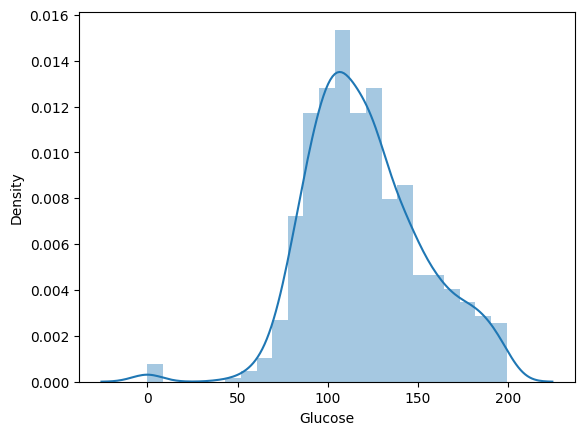

In [ ]:
sns.distplot(df.Glucose)

maybe mean

<ipython-input-17-3404a214f00d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.BloodPressure)


<Axes: xlabel='BloodPressure', ylabel='Density'>

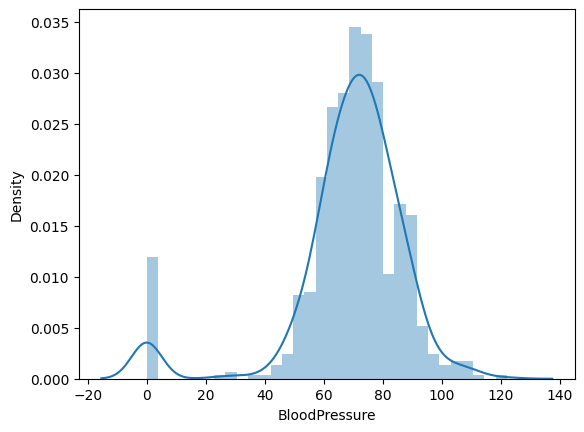

In [ ]:
sns.distplot(df.BloodPressure)

median

<ipython-input-18-d4621c29f1f7>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.SkinThickness)


<Axes: xlabel='SkinThickness', ylabel='Density'>

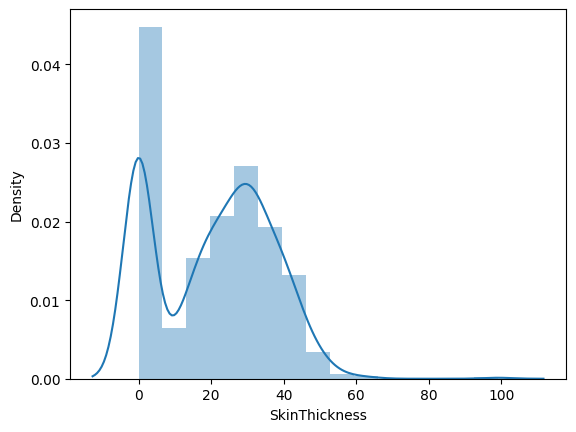

In [ ]:
sns.distplot(df.SkinThickness)

median

<ipython-input-19-332b7890e081>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Insulin)


<Axes: xlabel='Insulin', ylabel='Density'>

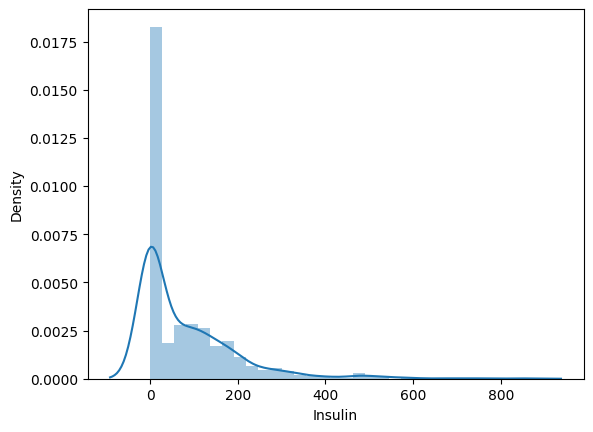

In [ ]:
sns.distplot(df.Insulin)

mean

<ipython-input-20-8e68ae17a522>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.BMI)


<Axes: xlabel='BMI', ylabel='Density'>

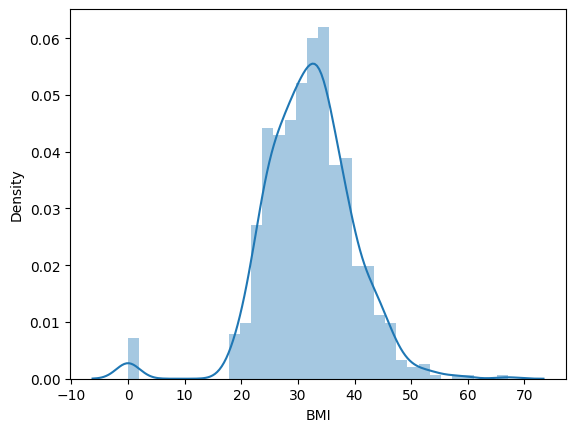

In [ ]:
sns.distplot(df.BMI)

median

<ipython-input-21-508baf36864a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.DiabetesPedigreeFunction)


<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

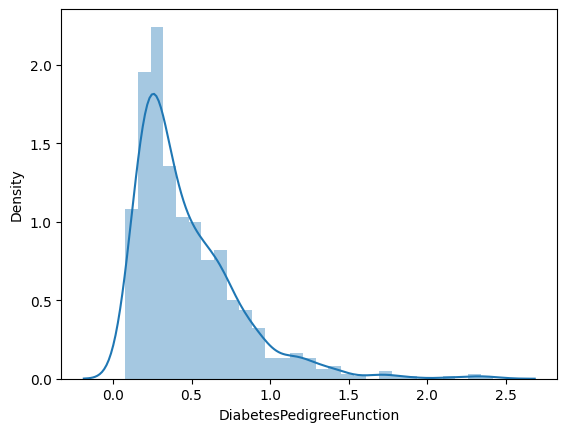

In [ ]:
sns.distplot(df.DiabetesPedigreeFunction)

median

<ipython-input-22-b2378c9d8a20>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Age)


<Axes: xlabel='Age', ylabel='Density'>

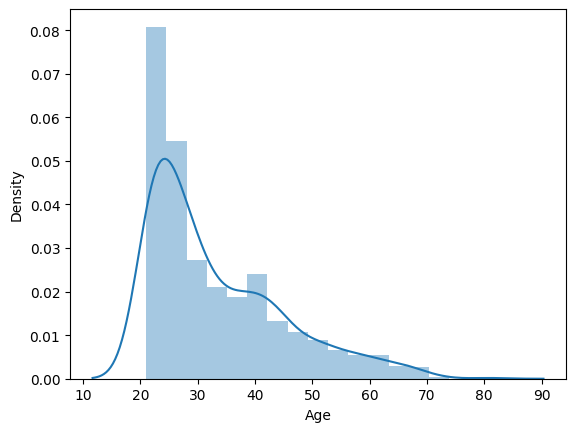

In [ ]:
sns.distplot(df.Age)

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df['Pregnancies']=df['Pregnancies'].replace(0,df['Pregnancies'].median())

In [ ]:
df['Glucose']=df['Glucose'].replace(0,df['Glucose'].median())

In [ ]:
df['BloodPressure']=df['BloodPressure'].replace(0,df['BloodPressure'].median())

In [ ]:
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].median())

In [ ]:
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].median())

In [ ]:
df['BMI']=df['BMI'].replace(0,df['BMI'].mean())

In [ ]:
df['DiabetesPedigreeFunction']=df['DiabetesPedigreeFunction'].replace(0,df['DiabetesPedigreeFunction'].median())

In [ ]:
df['Age']=df['Age'].replace(0,df['Age'].median())

Now no 0's

In [ ]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.600000,0.627,50,1
1,1,85,66,29,30.5,26.600000,0.351,31,0
2,8,183,64,23,30.5,23.300000,0.672,32,1
3,1,89,66,23,94.0,28.100000,0.167,21,0
4,3,137,40,35,168.0,43.100000,2.288,33,1
5,5,116,74,23,30.5,25.600000,0.201,30,0
6,3,78,50,32,88.0,31.000000,0.248,26,1
7,10,115,72,23,30.5,35.300000,0.134,29,0
8,2,197,70,45,543.0,30.500000,0.158,53,1
9,8,125,96,23,30.5,31.992578,0.232,54,1


*   Descriptive Statistics and it's significance
*   Correlation Coefficient and it's significance

*   Types of Distribution and it's significance
*   Median is more robuts to outliers and why

*   Data Imputation via Mean and Median(Numeric Data) => Symmetric -> Mean and Skewed -> Median, Categorical Data => Mode


In [ ]:
X=df.drop(columns='Outcome',axis=1)

In [ ]:
X #input data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,30.5,33.6,0.627,50
1,1,85,66,29,30.5,26.6,0.351,31
2,8,183,64,23,30.5,23.3,0.672,32
3,1,89,66,23,94.0,28.1,0.167,21
4,3,137,40,35,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63
764,2,122,70,27,30.5,36.8,0.340,27
765,5,121,72,23,112.0,26.2,0.245,30
766,1,126,60,23,30.5,30.1,0.349,47


In [ ]:
y=df['Outcome']

In [ ]:
y #target value

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


Outlier Detection --> **BoxPlot**

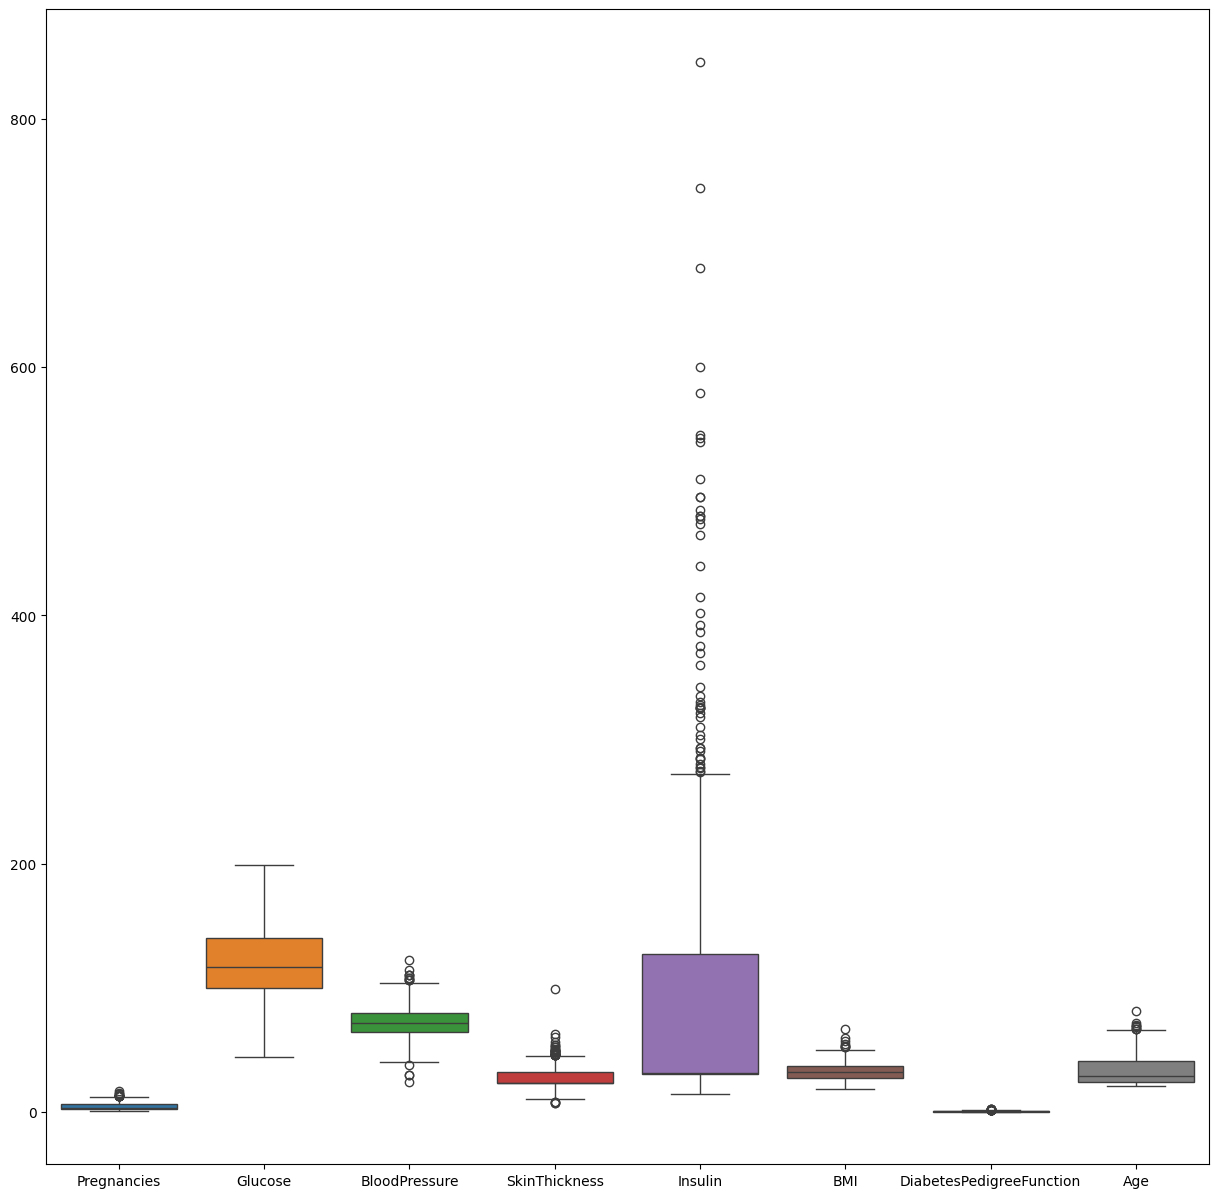

In [ ]:
fig,ax=plt.subplots(figsize=(15,15))
sns.boxplot(data=X,ax=ax)
plt.savefig('boxplot.jpg')
plt.show()

In [ ]:
X.shape

(768, 8)

In [ ]:
y.shape

(768,)

In [ ]:
for col in X.columns:
  Q1=X[col].quantile(0.25)
  Q3=X[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  mask=(X[col]>lower_bound) & (X[col]<upper_bound)
  X_outlier_removed=X[mask]
  y_outliers_removed=y[mask]

In [ ]:
X_outlier_removed.shape

(759, 8)

In [ ]:
y_outliers_removed.shape

(759,)

Normalization

Standard Normal Form
mean=0 standard deviation=1

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_norm=scaler.fit_transform(X_outlier_removed)

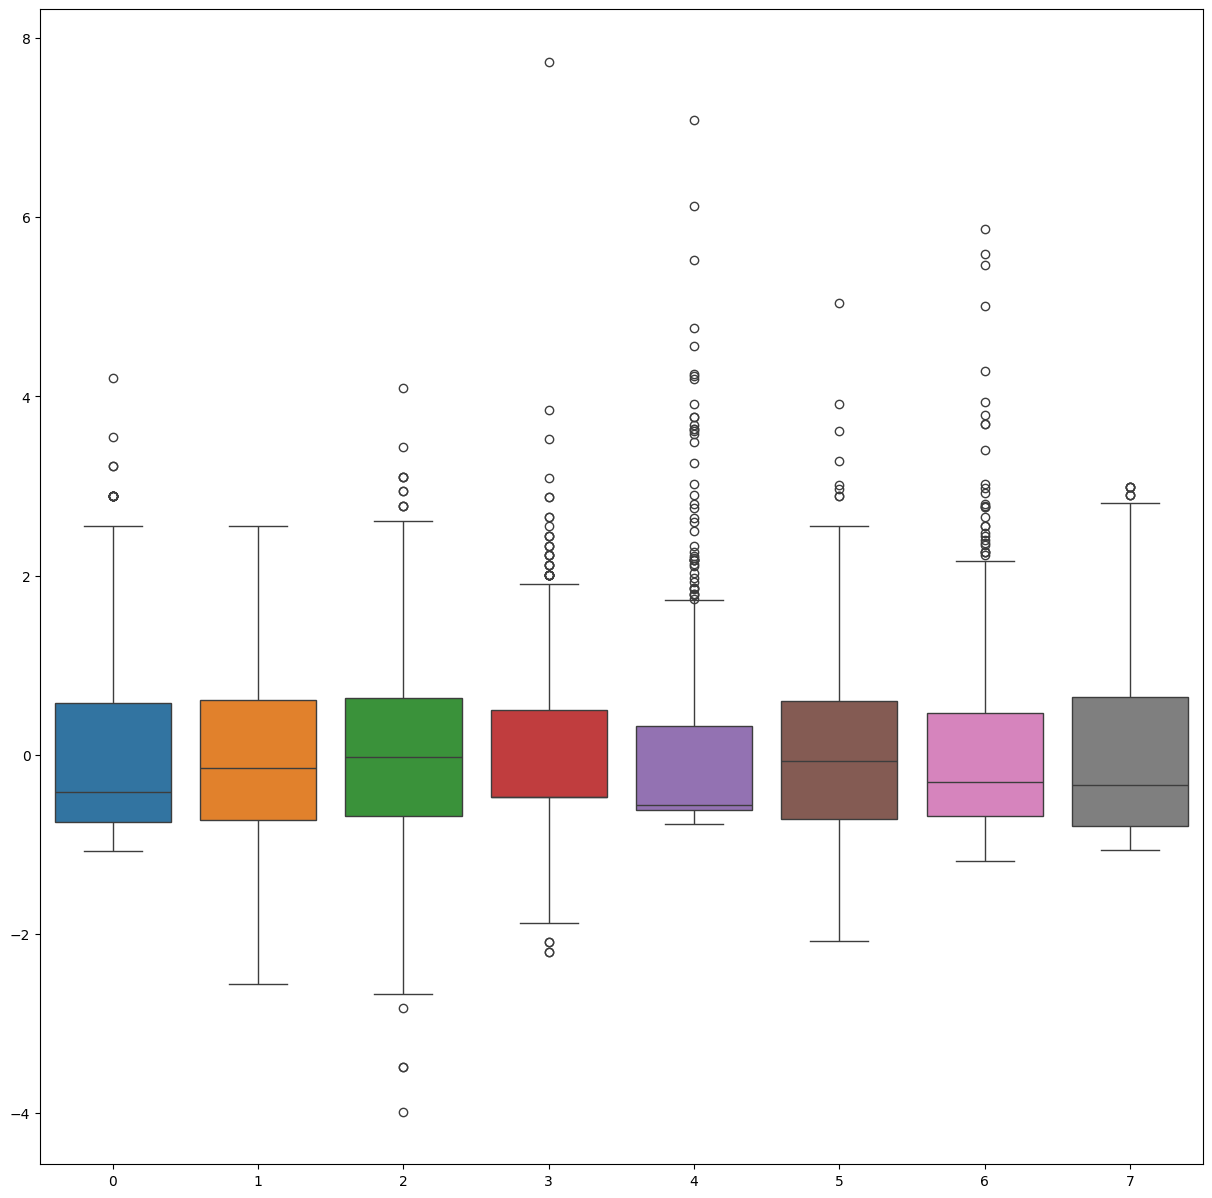

In [ ]:
fig,ax=plt.subplots(figsize=(15,15))
sns.boxplot(data=X_norm,ax=ax)
plt.savefig('boxplot_normalized.jpg')
plt.show()

In [ ]:
X_norm=pd.DataFrame(X_norm)

In [ ]:
X_norm.describe()

,0,1,2,3,4,5,6,7
count,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02
mean,1.029772e-16,2.176564e-16,-2.691450e-17,-1.509552e-16,-4.329724e-17,5.546727e-16,4.914821e-17,1.591466e-16
std,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00
min,-1.079800e+00,-2.557008e+00,-3.985285e+00,-2.200901e+00,-7.684941e-01,-2.081038e+00,-1.183313e+00,-1.062953e+00
25%,-7.491956e-01,-7.277108e-01,-6.872979e-01,-4.729631e-01,-6.126688e-01,-7.125819e-01,-6.852739e-01,-7.928253e-01
50%,-4.185912e-01,-1.509053e-01,-2.770048e-02,-4.729631e-01,-5.607270e-01,-7.202795e-02,-3.045975e-01,-3.426125e-01
75%,5.732217e-01,6.071820e-01,6.318969e-01,4.990017e-01,3.222827e-01,5.976421e-01,4.627740e-01,6.478556e-01
max,4.209869e+00,2.551840e+00,4.094783e+00,7.734740e+00,7.088876e+00,5.037846e+00,5.864467e+00,2.988962e+00


Approach 2 for removing outliers : **Quantiles**


In [ ]:
X_outlier_removed.reset_index(drop=True,inplace=True)
y_outliers_removed.reset_index(drop=True,inplace=True)

In [ ]:
q=X_outlier_removed['Insulin'].quantile(0.98)
mask=X_outlier_removed['Insulin']<q
X_outlier_removed_new=X_outlier_removed[mask]
y_outliers_removed=y_outliers_removed[mask]

In [ ]:
X_outlier_removed_new.shape

(743, 8)

In [ ]:
y_outliers_removed.shape

(743,)

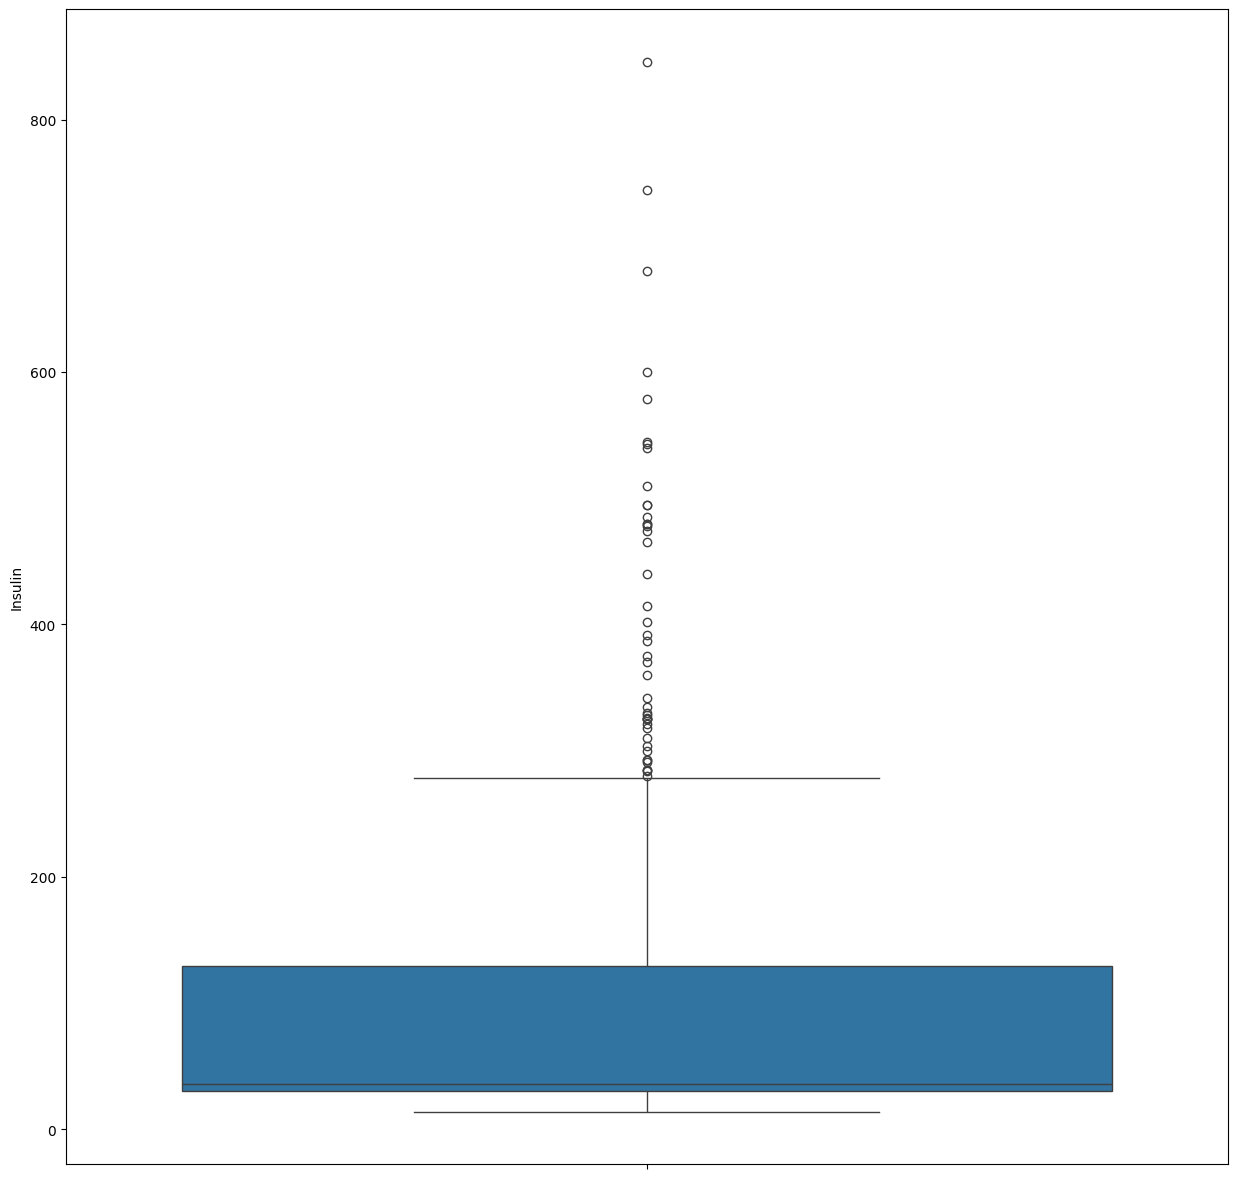

In [ ]:
fig,ax=plt.subplots(figsize=(15,15))
sns.boxplot(data=X_outlier_removed['Insulin'],ax=ax)
plt.savefig('boxplot_normalized_new.jpg')
plt.show()

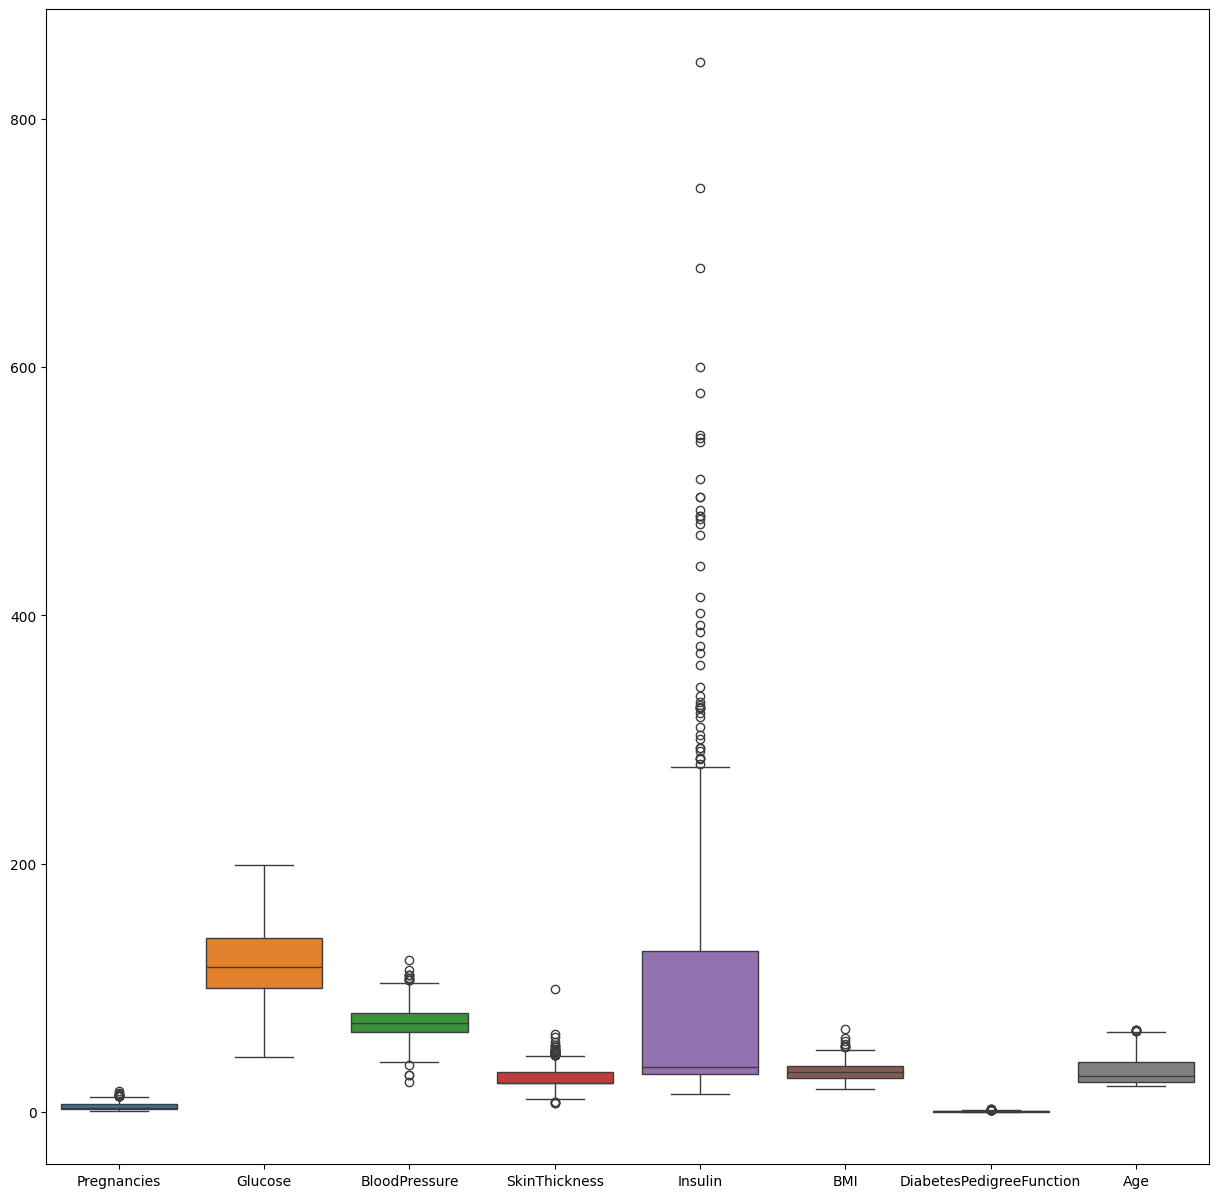

In [ ]:
fig,ax=plt.subplots(figsize=(15,15))
sns.boxplot(data=X_outlier_removed,ax=ax)
plt.savefig('boxplot_normalized_new.jpg')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X_outlier_removed_new,y_outliers_removed,test_size=0.3,random_state=42)

In [ ]:
x_train.shape

(520, 8)

In [ ]:
x_test.shape

(223, 8)

so much bais for 0 class


In [ ]:
    y_train.value_counts()

,count
Outcome,
0,339
1,181


In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

In [ ]:
print(pd.Series(y_train_smote).value_counts())

Outcome
1    339
0    339
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_smote,y_train_smote)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

target_names=['Diabetic','Non Diabetic']
print(classification_report(y_test,y_pred,target_names=target_names))

confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

    Diabetic       0.85      0.81      0.83       149
Non Diabetic       0.65      0.70      0.68        74

    accuracy                           0.78       223
   macro avg       0.75      0.76      0.75       223
weighted avg       0.78      0.78      0.78       223



array([[121,  28],
       [ 22,  52]])

In [ ]:
import pickle
pickle.dump(model,open('diabetes_pred_model.pkl','wb'))